# Summary
We have used the python module  **networkx**  to analyze the relation between kaggle users in team competitions. We have found out who are the most connected ones and we have build a user recommender based on the rule: "the friends of my friends are also my friends".


## Data loading

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
users_df = pd.read_csv("../input/Users.csv")

In [3]:
teams_df = pd.read_csv("../input/Teams.csv", low_memory=False)
teams_df['Score'] = teams_df['Score'].astype(float)

In [4]:
user_teams_df = pd.read_csv("../input/TeamMemberships.csv") 

In [5]:
user_teams_df.head()

,Id,TeamId,UserId
0,16436,496,647
1,16437,497,619
2,16438,499,663
3,16439,500,673
4,16440,501,435


## Analysis

Let's see the size of the teams. Most of them have size 1 but there are a small amout which are very big:

In [6]:
teams_size = user_teams_df.groupby("TeamId")['UserId'].count()
teams_size = teams_size.sort_values(ascending=False)

In [7]:
teams_size.head()

TeamId
9021     40
74305    25
77642    24
41125    24
41126    24
Name: UserId, dtype: int64

In [8]:
teams_df[teams_df['Id']==9021]

,Id,TeamName,CompetitionId,TeamLeaderId,Score,Ranking,ScoreFirstSubmittedDate,IsBenchmark,GithubRepoLink
4444,9021,Concrete Narwhal,2589,22958,0.81553,30,2011-11-23 20:31:54,False,NaN


In [9]:
teams_size.describe()

count    97187.000000
mean         1.140420
std          0.626557
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: UserId, dtype: float64

More than 91% of the teams have only 1 participant. 

In [10]:
from scipy import stats
stats.percentileofscore(teams_size, 1, kind='weak')

91.820922551370046

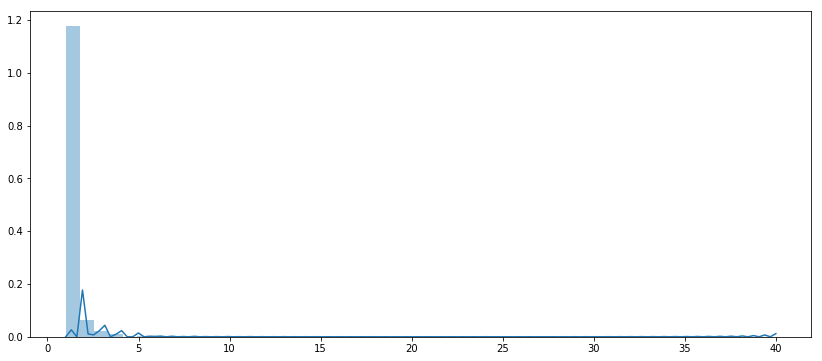

In [11]:
plt.figure(figsize=(14, 6))
sns.distplot(teams_size.values)
plt.show()

In [12]:
import networkx as nx

In [13]:
from itertools import combinations
teams_graph = nx.MultiGraph()
teams_graph.add_nodes_from(user_teams_df['UserId'].unique())

In [14]:
len(teams_graph.nodes())

56535

In [15]:
grouped = user_teams_df.groupby('TeamId')
for name, group in grouped:
    for n1, n2 in combinations(group['UserId'].values, 2):
        teams_graph.add_edge(n1, n2, TeamId=name)

In [16]:
teams_graph.edges(data=True)[:10]

[(722, 727, {'TeamId': 504}),
 (694, 71953, {'TeamId': 32684}),
 (842, 819, {'TeamId': 75608}),
 (820, 879, {'TeamId': 532}),
 (819, 821, {'TeamId': 533}),
 (899, 902, {'TeamId': 542}),
 (887, 13535, {'TeamId': 5488}),
 (835, 875, {'TeamId': 4766}),
 (835, 18347, {'TeamId': 4766}),
 (835, 18347, {'TeamId': 19656})]

In [17]:
len(teams_graph.edges())

26858

In [18]:
user_teams_df.loc[user_teams_df['TeamId']==1000, 'UserId'].values

array([811])

In [19]:
teams_graph[811]

{}

In [20]:
user_teams_df.loc[user_teams_df['TeamId']==9021, 'UserId'].values

array([13525, 16399, 17982, 19369, 21224, 22659, 22958, 23084, 23086,
       23101, 23124, 23140, 23171, 23188, 23277, 23368, 23468, 23472,
       23499, 23500, 23590, 23605, 23616, 23661, 23742, 23779, 23785,
       23813, 23825, 23893, 23905, 24160, 24415, 24445, 24446, 24478,
       24545, 24650, 24671, 24762])

In [21]:
user_teams_df.loc[user_teams_df['UserId']==16399]

,Id,TeamId,UserId
4828,25362,9021,16399
5502,25465,10450,16399


We calculate the degrees of centrality to see which are the most important nodes:

In [22]:
degrees = {n: len(teams_graph.neighbors(n)) for n in teams_graph.nodes()}

In [23]:
max(degrees, key=degrees.get)

24478

In [24]:
print("Neighbors: {} Edges: {}".format(degrees[24478], len(teams_graph.edges(24478))))

Neighbors: 49 Edges: 58


The kaggle user most connected in teams with other users is the number *24478*  ([Mariahbarrio](https://www.kaggle.com/Mariahbarrio)) who is connected to *49* users

In [25]:
users_df[users_df.Id==24478]

,Id,UserName,DisplayName,RegisterDate,Points,Ranking,Tier,HighestRanking
21051,24478,NaN,Mariahbarrio,2011-11-24 17:19:36,88.900002,36537.0,4,1081.0


In [26]:
deg_cent = nx.degree_centrality(teams_graph)

In [27]:
max(deg_cent, key=deg_cent.get)

97201

The user with higher degree of centrality is *97201* ([jimmykuo](https://www.kaggle.com/jimmykuo)). That's because although he has not so many neighbors as *24478* , he is near and has participated more times with them

In [28]:
users_df[users_df.Id==97201]

,Id,UserName,DisplayName,RegisterDate,Points,Ranking,Tier,HighestRanking
89066,97201,jimmykuo,JMY!!,2013-04-23 13:03:25,2730.699951,2820.0,10,157.0


In [29]:
print("Neighbors: {} Edges: {}".format(degrees[97201], len(teams_graph.edges(97201))))

Neighbors: 45 Edges: 91


Let's see the cliques of the graph:

In [30]:
cliques = list(nx.find_cliques(teams_graph))

In [31]:
len(cliques)

47121

In [32]:
max(list(map(len, cliques)))

40

We are going to process our previous graph to obtain a non directed and non multigraph graph: each node will be connected with other no more than 1 time (1 edge) but we will add an edge attribute with the times the two nodes (kaggle users) has been in a team together. This way the resulting graph will have less edges and less nodes (only non individual participants are included)

In [33]:
from collections import defaultdict
tmp = defaultdict(int)
for n1, n2 in teams_graph.edges():
    tmp[(n1, n2)] += 1

In [34]:
G = nx.Graph()
for u, v, d in teams_graph.edges_iter(data=True):
    if G.has_edge(u,v):
        G[u][v]['weight'] += 1
    else:
        G.add_edge(u, v, weight=1)

In [35]:
G.edges(data=True)[:10]

[(722, 727, {'weight': 1}),
 (694, 71953, {'weight': 1}),
 (842, 819, {'weight': 1}),
 (819, 821, {'weight': 1}),
 (820, 879, {'weight': 1}),
 (899, 902, {'weight': 1}),
 (887, 13535, {'weight': 1}),
 (835, 875, {'weight': 1}),
 (835, 18347, {'weight': 2}),
 (835, 33898, {'weight': 1})]

In [36]:
len(G.nodes())

15857

In [37]:
len(G.edges())

22222

In [38]:
cliques_2 = list(nx.find_cliques(G))

In [39]:
len(cliques)

47121

In [40]:
len(G.nodes())

15857

In this case, the max degree of centrailty is for the user with more neighbors, altough he is not who has been in more teams:

In [41]:
deg_cent_2 = nx.degree_centrality(G)
max(deg_cent_2, key=deg_cent_2.get)

24478

In [42]:
user_teams_df.loc[user_teams_df['UserId']==24478]

,Id,TeamId,UserId
4862,24716,9021,24478
6388,27338,12128,24478
6595,27935,12565,24478


In [43]:
user_teams_df.loc[user_teams_df['UserId']==97201]

,Id,TeamId,UserId
16926,59483,41125,97201
16950,59487,41126,97201
27787,99805,77642,97201
31142,115036,89982,97201
48190,163498,135825,97201


In [44]:
user_teams_df.head()

,Id,TeamId,UserId
0,16436,496,647
1,16437,497,619
2,16438,499,663
3,16439,500,673
4,16440,501,435


These are the users who have participated in more teams (One of the users have participated in 106 teams, although most of the time with the same people):

In [45]:
user_teams_df.groupby('UserId')['TeamId'].agg(['count']) \
    .sort_values(by=['count'], ascending=False).head(20)

,count
UserId,
16491,106
5309,90
808,88
50689,84
19298,82
41959,81
33622,75
114978,75
54720,68


In [46]:
users_df[users_df.Id==16491]

,Id,UserName,DisplayName,RegisterDate,Points,Ranking,Tier,HighestRanking
13981,16491,invinciblejha,Vikram Jha,2011-09-17 08:27:01,23258.900391,223.0,4,42.0


In [47]:
len(G.neighbors(16491))

12

## User recommendation
We are going to create an user recommendator, similar to user suggested friends. The base of the recommendator will be: if a user "A" has been in a team with "B" and "B" has been in a team with "C", but "A" and "C" have never  been in a team, we will recommend "C" to the user "A". This technique es called "finding open triangles".

In [48]:
recommended = defaultdict(int)
for n, d in G.nodes(data=True):
    for n1, n2 in combinations(G.neighbors(n), 2):
        if not G.has_edge(n1, n2):
            recommended[(n1, n2)] += 1

In [49]:
# Identify the top pairs of users
all_counts = sorted(recommended.values())
top_pairs = [pair for pair, count in recommended.items() if count > 5]
print(top_pairs)

[(5309, 99029), (1455, 54836), (41959, 363731), (134751, 394905), (134751, 460599), (134751, 518387), (255519, 351973), (255519, 518387), (96225, 167701), (129492, 167701), (166981, 167701), (140403, 164591), (159734, 164591), (160536, 164591), (161349, 164591)]


In [50]:
[recommended[e] for e in top_pairs]

[8, 7, 7, 7, 7, 6, 8, 7, 21, 21, 21, 21, 21, 21, 21]

In [51]:
max_pairs = [pair for pair, count in recommended.items() if count ==21]

Someone should present these people because they have a lot of contacts in common:

In [52]:
max_pairs

[(96225, 167701),
 (129492, 167701),
 (166981, 167701),
 (140403, 164591),
 (159734, 164591),
 (160536, 164591),
 (161349, 164591)]

In [53]:
from IPython.display import HTML
users_df.head()

,Id,UserName,DisplayName,RegisterDate,Points,Ranking,Tier,HighestRanking
0,1,kaggle,Kaggle,2011-03-24 02:17:07,NaN,NaN,1,NaN
1,368,antgoldbloom,Anthony Goldbloom,2010-01-20 01:07:25,981.099976,7055.0,4,75.0
2,381,iguyon,Isabelle,2010-01-29 20:07:37,308.399994,17576.0,4,2824.0
3,383,NaN,David Stephan,2010-02-01 04:03:43,NaN,NaN,1,NaN
4,384,NaN,Gabe Warren,2010-02-02 00:18:02,NaN,NaN,1,NaN


In [54]:
recommend = pd.DataFrame(max_pairs, columns=['user1', 'user2'])

for i in range(len(recommend)):
    tmp_id1 = recommend.loc[i, "user1"]
    tmp_username1 = users_df.loc[users_df.Id==tmp_id1, "DisplayName"].values[0]
    
    tmp_id2 = recommend.loc[i, "user2"]
    tmp_username2 = users_df.loc[users_df.Id==tmp_id2, "DisplayName"].values[0]    

    recommend.loc[i, "user1"] = "<a target='_blank' href='https://www.kaggle.com/u/" \
        + str(tmp_id1) + "'>" + tmp_username1 + "<" + "/a>"
    recommend.loc[i, "user2"] = "<a target='_blank' href='https://www.kaggle.com/u/" \
        + str(tmp_id2) + "'>" + tmp_username2 + "<" + "/a>"        


In [55]:
pd.set_option("display.max_colwidth", -1)
HTML(recommend.to_html(escape=False))

,user1,user2
0,Ruei Bin Wang,paul112004
1,Li Chun Yang,paul112004
2,x32768,paul112004
3,Kevin Kuate Fodouop,dzangri
4,Sijia,dzangri
5,Stephen Kent,dzangri
6,ACE-2488,dzangri


Let's try subgraphs. We are going to build a subgraph of the neighbors of the user 24478 (the one with most neighbors) and himself

In [56]:
G_maxconnected = G.subgraph(G.neighbors(24478) + [24478])

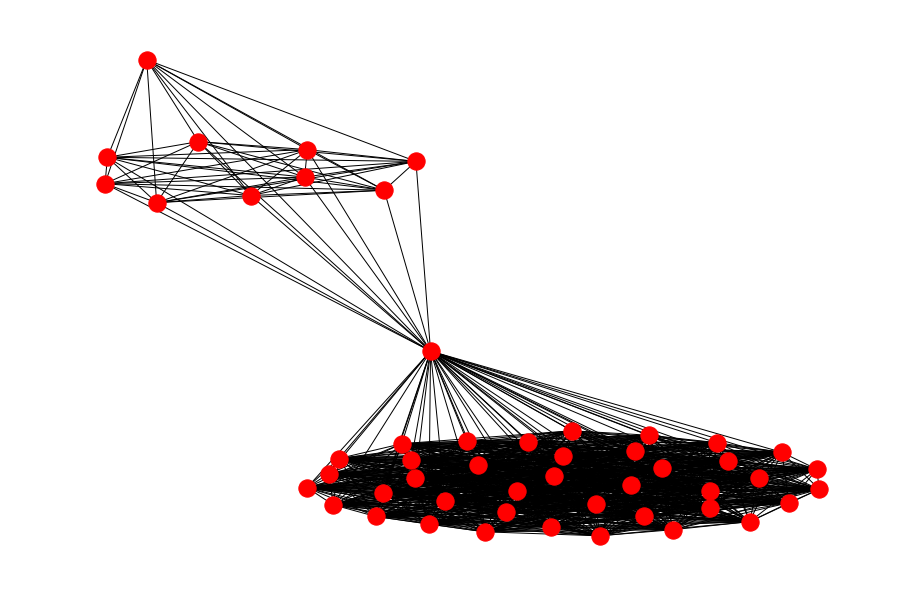

In [57]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(12,8))
nx.draw(G_maxconnected)
plt.show()

It looks like that the user 24478 connects two different cliques: 

In [58]:
cliques_2 = list(nx.find_cliques(G_maxconnected))

In [59]:
len(cliques_2)

2